In [23]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import numpy as np
import matplotlib.pyplot as plt
import math
import h5py
import h5

In [2]:
sim = Simulation("TED")
switchOffAllEffects(sim)
sim["ObservingParameters/NumExposures"] = 1
sim.outputDir = os.environ["PLATO_WORKDIR"]

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"

position = 4000
dim = 100
numSubPixels = sim["SubField/SubPixels"]

sim.createStarCatalogFileFromPixelCoordinates(np.array([position]), np.array([position]), np.array([12.5]), np.array([1]), starCatalogFilename)
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim
sim["SubField/ZeroPointRow"] = position - dim // 2
sim["SubField/ZeroPointColumn"] = position - dim // 2
    

sim["PSF/Model"] = "MappedGaussian"
sim["CCD/IncludeConvolution"] = "yes"

sim["Telescope/UseDrift"] = "yes"
sim["Telescope/UseDriftFromFile"] = "yes"

In [3]:
driftTimeScale = 0.1
drift = 50

numDriftSteps = int(25 / driftTimeScale) * 500
time = np.arange(numDriftSteps) * driftTimeScale
noChange = np.zeros(numDriftSteps)
change = np.arange(numDriftSteps) * drift

driftFilenameYaw = os.environ["PLATO_WORKDIR"] + "yawDrift.txt"
driftFilenamePitch = os.environ["PLATO_WORKDIR"] + "pitchDrift.txt"
driftFilenameRoll = os.environ["PLATO_WORKDIR"] + "rollDrift.txt"

np.savetxt(driftFilenameYaw, np.c_[time, change, noChange, noChange])
np.savetxt(driftFilenamePitch, np.c_[time, noChange, change, noChange])
np.savetxt(driftFilenameRoll, np.c_[time, noChange, noChange, change])

sim["ControlHDF5Content/WriteStarPositions"] = "yes"

In [4]:
drift2 = drift

driftTimeScale2 = 25
numDriftSteps2 = int(25 / driftTimeScale2) * 500
time2 = np.arange(numDriftSteps2) * driftTimeScale2
noChange2 = np.zeros(numDriftSteps2)
change2 = np.arange(numDriftSteps2) * drift2

driftFilenameYaw2 = os.environ["PLATO_WORKDIR"] + "yawDrift2.txt"
driftFilenamePitch2 = os.environ["PLATO_WORKDIR"] + "pitchDrift2.txt"
driftFilenameRoll2 = os.environ["PLATO_WORKDIR"] + "rollDrift2.txt"

np.savetxt(driftFilenameYaw2, np.c_[time2, change2, noChange2, noChange2])
np.savetxt(driftFilenamePitch2, np.c_[time2, noChange2, change2, noChange2])
np.savetxt(driftFilenameRoll2, np.c_[time2, noChange2, noChange2, change2])

# Change in yaw only (exaggerated)

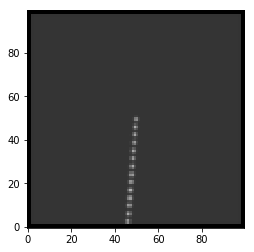

In [5]:
sim["Telescope/DriftFileName"] = driftFilenameYaw

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

im = output.getImage(0)
plt.imshow(im, origin = "lower", cmap='gray', vmin = 5800, vmax = 6100)

In [6]:
sim["Telescope/DriftFileName"] = driftFilenameYaw2

numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

Error: SimfFile.getStarCoordinates(): Exposure000014 not in hdf5 file


Text(0, 0.5, 'y [pixels]')

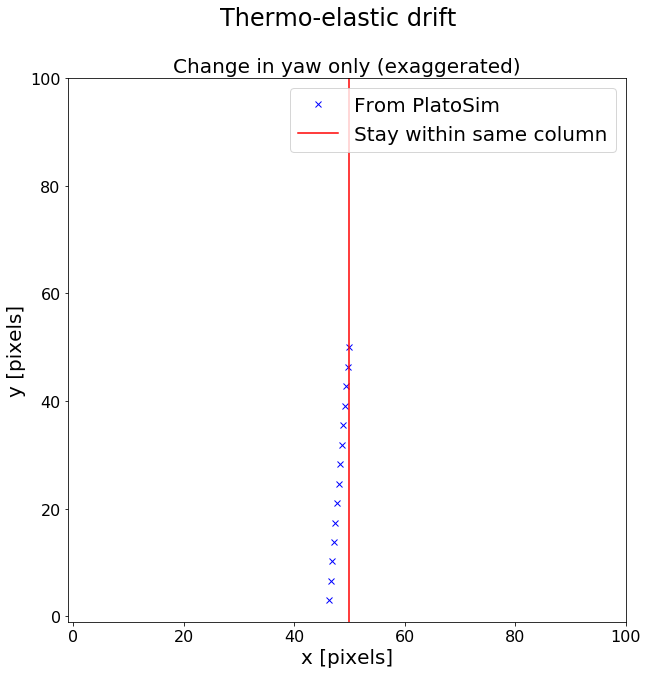

In [7]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

rows = np.array([])
columns = np.array([])

for exposure in range(60):
    try:
        ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
        rows = np.append(rows, row)
        columns = np.append(columns, column)
    except:
        break

plt.plot(columns, rows, "bx", label = "From PlatoSim")

    
    
###############
# Change in row
###############

plt.axvline(x = dim / 2, color = "r", label = "Stay within same column")



########
# Layout
########

plt.xlim([-1, dim])
plt.ylim([-1, dim])

plt.suptitle("Thermo-elastic drift", fontsize = 24)
plt.title("Change in yaw only (exaggerated)", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("x [pixels]", fontsize = 20)
plt.ylabel("y [pixels]", fontsize = 20)

# Change in pitch only (exaggerated)

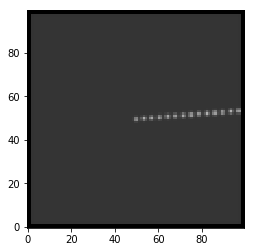

In [8]:
sim["Telescope/DriftFileName"] = driftFilenamePitch

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures
output = sim.run(removeOutputFile = True)

im = output.getImage(0)
plt.imshow(im, origin = "lower", cmap='gray', vmin = 5800, vmax = 6100)

In [9]:
sim["Telescope/DriftFileName"] = driftFilenamePitch2

numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

Error: SimfFile.getStarCoordinates(): Exposure000014 not in hdf5 file


Text(0, 0.5, 'y [pixels]')

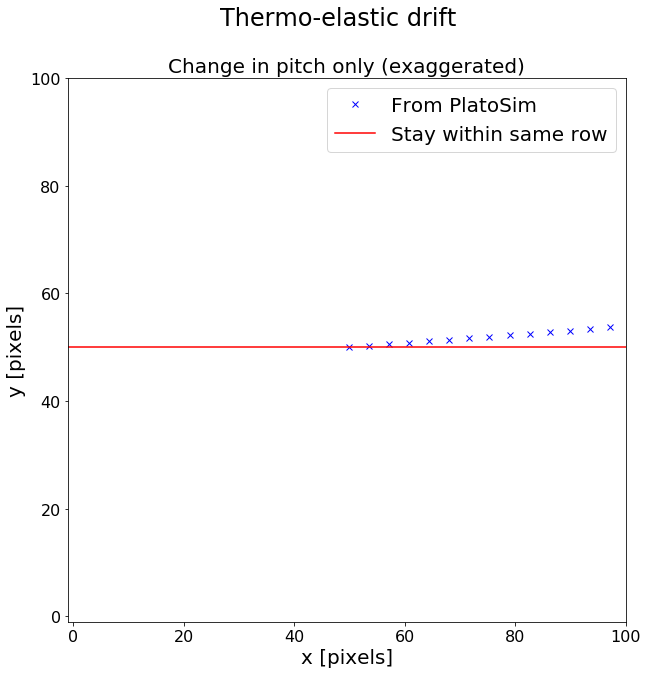

In [10]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

rows = np.array([])
columns = np.array([])

for exposure in range(numExposures):
    try:
        ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
        rows = np.append(rows, row)
        columns = np.append(columns, column)
    except:
        break

plt.plot(columns, rows, "bx", label = "From PlatoSim")



##################
# Change in column
##################

plt.axhline(y = dim / 2, color = "r", label = "Stay within same row")

    
    
########
# Layout
########

plt.xlim([-1, dim])
plt.ylim([-1, dim])

plt.suptitle("Thermo-elastic drift", fontsize = 24)
plt.title("Change in pitch only (exaggerated)", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("x [pixels]", fontsize = 20)
plt.ylabel("y [pixels]", fontsize = 20)

# Change in roll only (exaggerated)

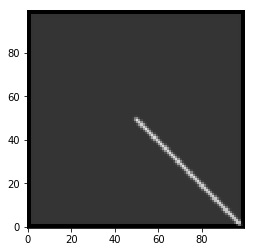

In [11]:
sim["Telescope/DriftFileName"] = driftFilenameRoll

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures
output = sim.run(removeOutputFile = True)

im = output.getImage(0)
plt.imshow(im, origin = "lower", cmap='gray', vmin = 5800, vmax = 6100)

In [12]:
sim["Telescope/DriftFileName"] = driftFilenameRoll2

numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

Error: SimfFile.getStarCoordinates(): Exposure000052 not in hdf5 file


Text(0, 0.5, '$y_{CCD} [pixels]$')

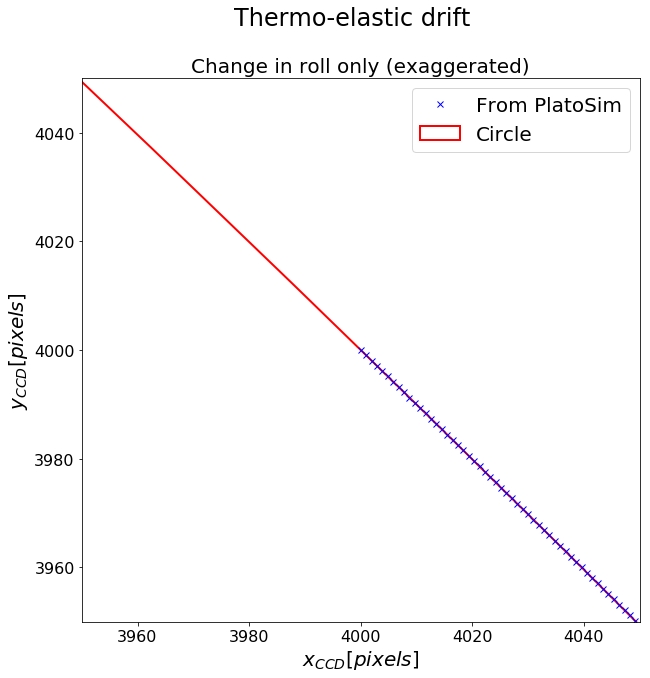

In [13]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

rows = np.array([])
columns = np.array([])

for exposure in range(numExposures):
    try:
        ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
        rows = np.append(rows, row)
        columns = np.append(columns, column)
    except:
        break

plt.plot(columns + position - dim//2, rows + position - dim//2, "bx", label = "From PlatoSim")



##################
# Change in column
##################

radiusSquared = 2 * (position**2)
circ = plt.Circle((0,0), radius = math.sqrt(radiusSquared), color = "white", linewidth = 2, label = "Circle")
ax.add_patch(circ)
circ.set_edgecolor("r")
circ.set_facecolor("none")

    
    
########
# Layout
########

plt.xlim([position - 50, position + 50])
plt.ylim([position - 50, position + 50])

plt.suptitle("Thermo-elastic drift", fontsize = 24)
plt.title("Change in roll only (exaggerated)", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("$x_{CCD} [pixels]$", fontsize = 20)
plt.ylabel("$y_{CCD} [pixels]$", fontsize = 20)

# Auto-generated TED

In [44]:
sim["Telescope/UseDriftFromFile"] = "no"

# rmsYaw = 2.0
# rmsPitch = 3.0
# rmsRoll = 4.0

sim["Telescope/DriftYawRms"] = rmsYaw
sim["Telescope/DriftPitchRms"] = rmsPitch
sim["Telescope/DriftRollRms"] = rmsRoll

sim["SubField/NumRows"] = 1
sim["SubField/NumColumns"] = 1

numExposures = 10000
sim["ObservingParameters/NumExposures"] = numExposures
output = sim.run(removeOutputFile = True)


2019-05-28 12:29:54 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 12:29:54 WARNING Camera: No star positions to write to HDF5 file.



In [45]:
hfile = h5py.File(os.environ["PLATO_WORKDIR"] + "TED.hdf5", 'r')

yaw = h5.h5get(hfile, ["Telescope", "TelescopeYaw"], verbose = False)
pitch = h5.h5get(hfile, ["Telescope", "TelescopePitch"], verbose = False)
roll = h5.h5get(hfile, ["Telescope", "TelescopeRoll"], verbose = False)

### Yaw

Text(0, 0.5, 'Yaw [degrees]')

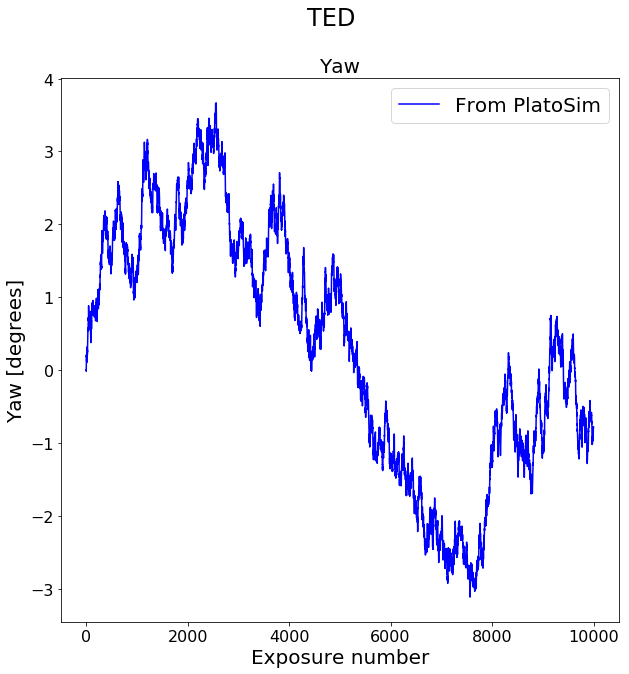

In [46]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(yaw, "b", label = "From PlatoSim")




########
# Layout
########

plt.suptitle("TED", fontsize = 24)
plt.title("Yaw", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Yaw [degrees]", fontsize = 20)

Text(0, 0.5, 'PSD')

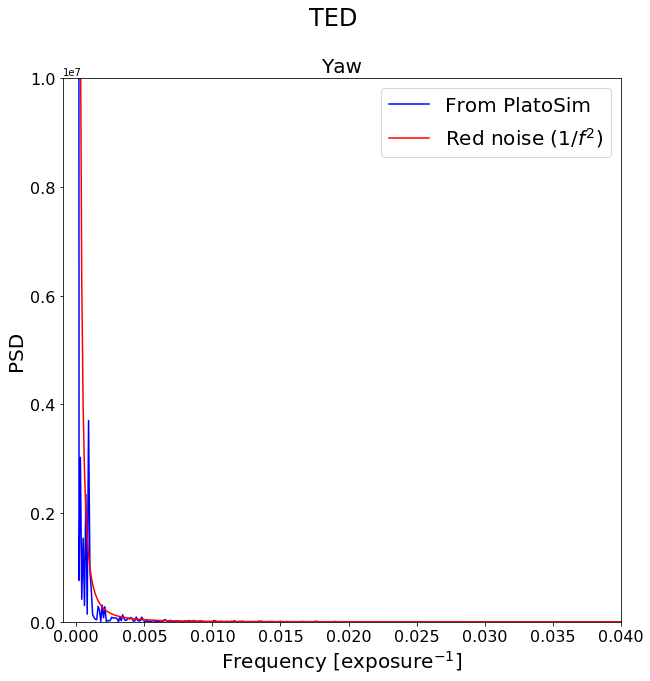

In [47]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(yaw)
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))

plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

plt.xlim([-0.001, 0.04])
plt.ylim([0, 10000000])

plt.suptitle("TED", fontsize = 24)
plt.title("Yaw", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)

### Pitch

Text(0, 0.5, 'Pitch [degrees]')

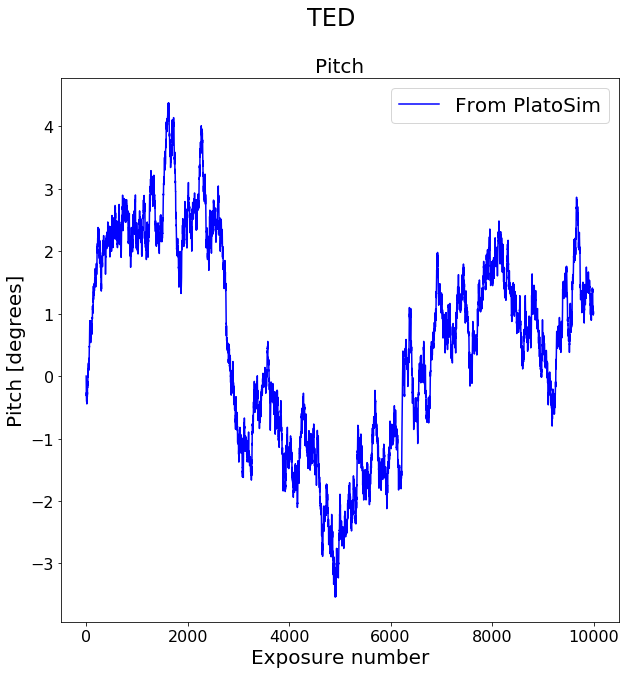

In [48]:
fig = plt.figure(figsize = (10, 10))



###############
# From PlatoSim
###############

ax = fig.add_subplot(1, 1, 1)
plt.plot(pitch, "b", label = "From PlatoSim")




########
# Layout
########

plt.suptitle("TED", fontsize = 24)
plt.title("Pitch", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Pitch [degrees]", fontsize = 20)

Text(0, 0.5, 'PSD')

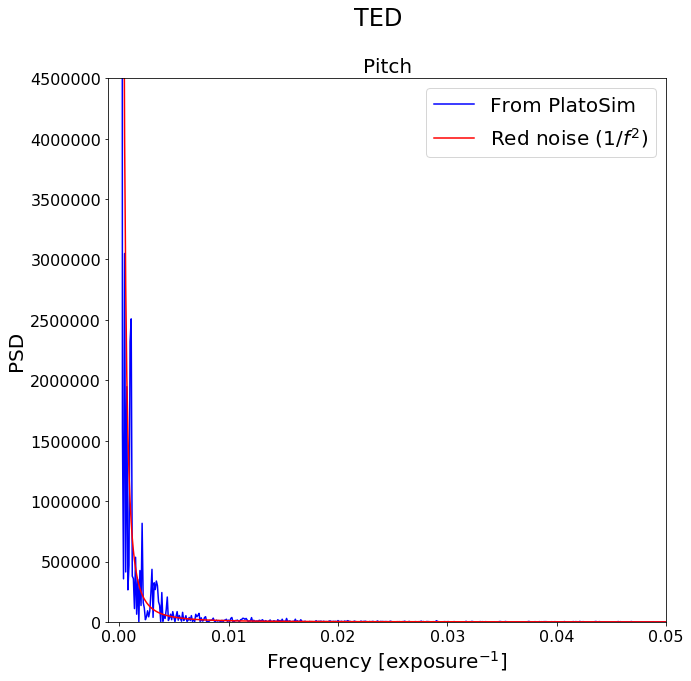

In [49]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(pitch)
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))

plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

plt.xlim([-0.001, 0.05])
plt.ylim([0, 4500000])

plt.suptitle("TED", fontsize = 24)
plt.title("Pitch", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)

### Roll

Text(0, 0.5, 'Roll [degrees]')

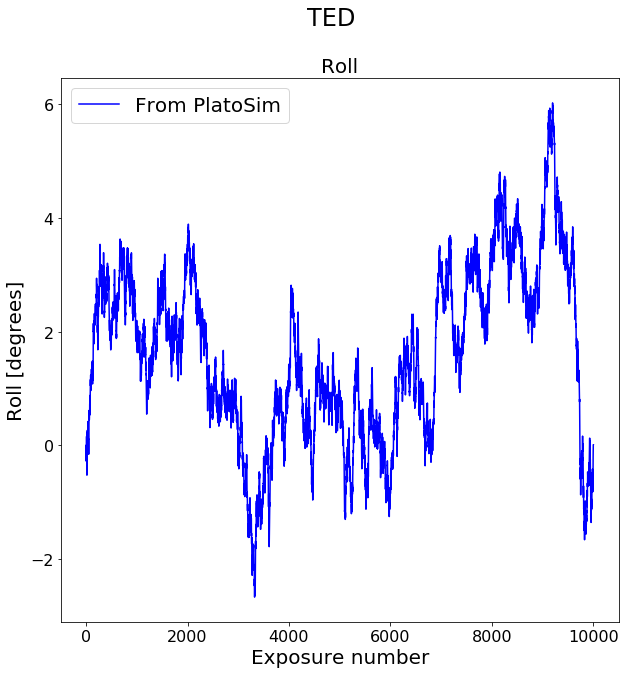

In [50]:
fig = plt.figure(figsize = (10, 10))



###############
# From PlatoSim
###############

ax = fig.add_subplot(1, 1, 1)
plt.plot(roll, "b", label = "From PlatoSim")




########
# Layout
########

plt.suptitle("TED", fontsize = 24)
plt.title("Roll", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Roll [degrees]", fontsize = 20)

Text(0, 0.5, 'PSD')

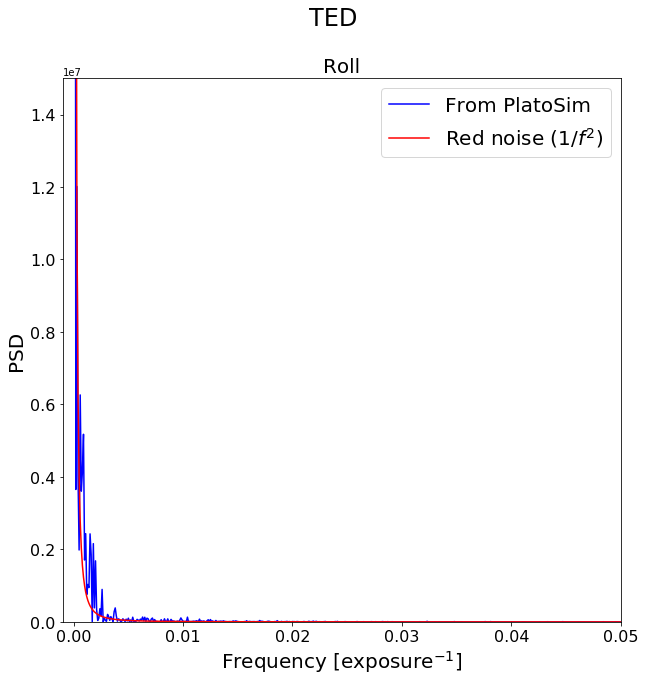

In [51]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(roll)
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))

plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

plt.xlim([-0.001, 0.05])
plt.ylim([0, 15000000])

plt.suptitle("TED", fontsize = 24)
plt.title("Roll", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)